# ANN Based on diabetes prediction using Pytorch.

In [1]:
import pandas as pd
import numpy as np
d1 = pd.read_csv('diabetes.csv')   #### Importing the PIMA Indian Diabetes Dataset from Kaggle
d2 = pd.read_csv('indian_diabetes_synthetic_100k.csv')
df = pd.concat([d1,d2])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [3]:
# Replace Zero values in important features with median value
df['Glucose'] = df['Glucose'].replace(0, np.median(df['Glucose']))

df['BloodPressure'] = df['BloodPressure'].replace(0, np.median(df['BloodPressure']))

df['SkinThickness'] = df['SkinThickness'].replace(0, np.median(df['SkinThickness']))

df['Insulin'] = df['Insulin'].replace(0, np.median(df['Insulin']))

df['BMI'] = df['BMI'].replace(0, np.median(df['BMI']))

In [4]:
import seaborn as sns

In [5]:

df['Outcome']=np.where(df['Outcome']==1,"Diabetic","No Diabetic") 
### replacing quantitative values with qualitative values

In [6]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,49,33.6,0.627,50,Diabetic
1,1,85,66,29,49,26.6,0.351,31,No Diabetic
2,8,183,64,27,49,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,No Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


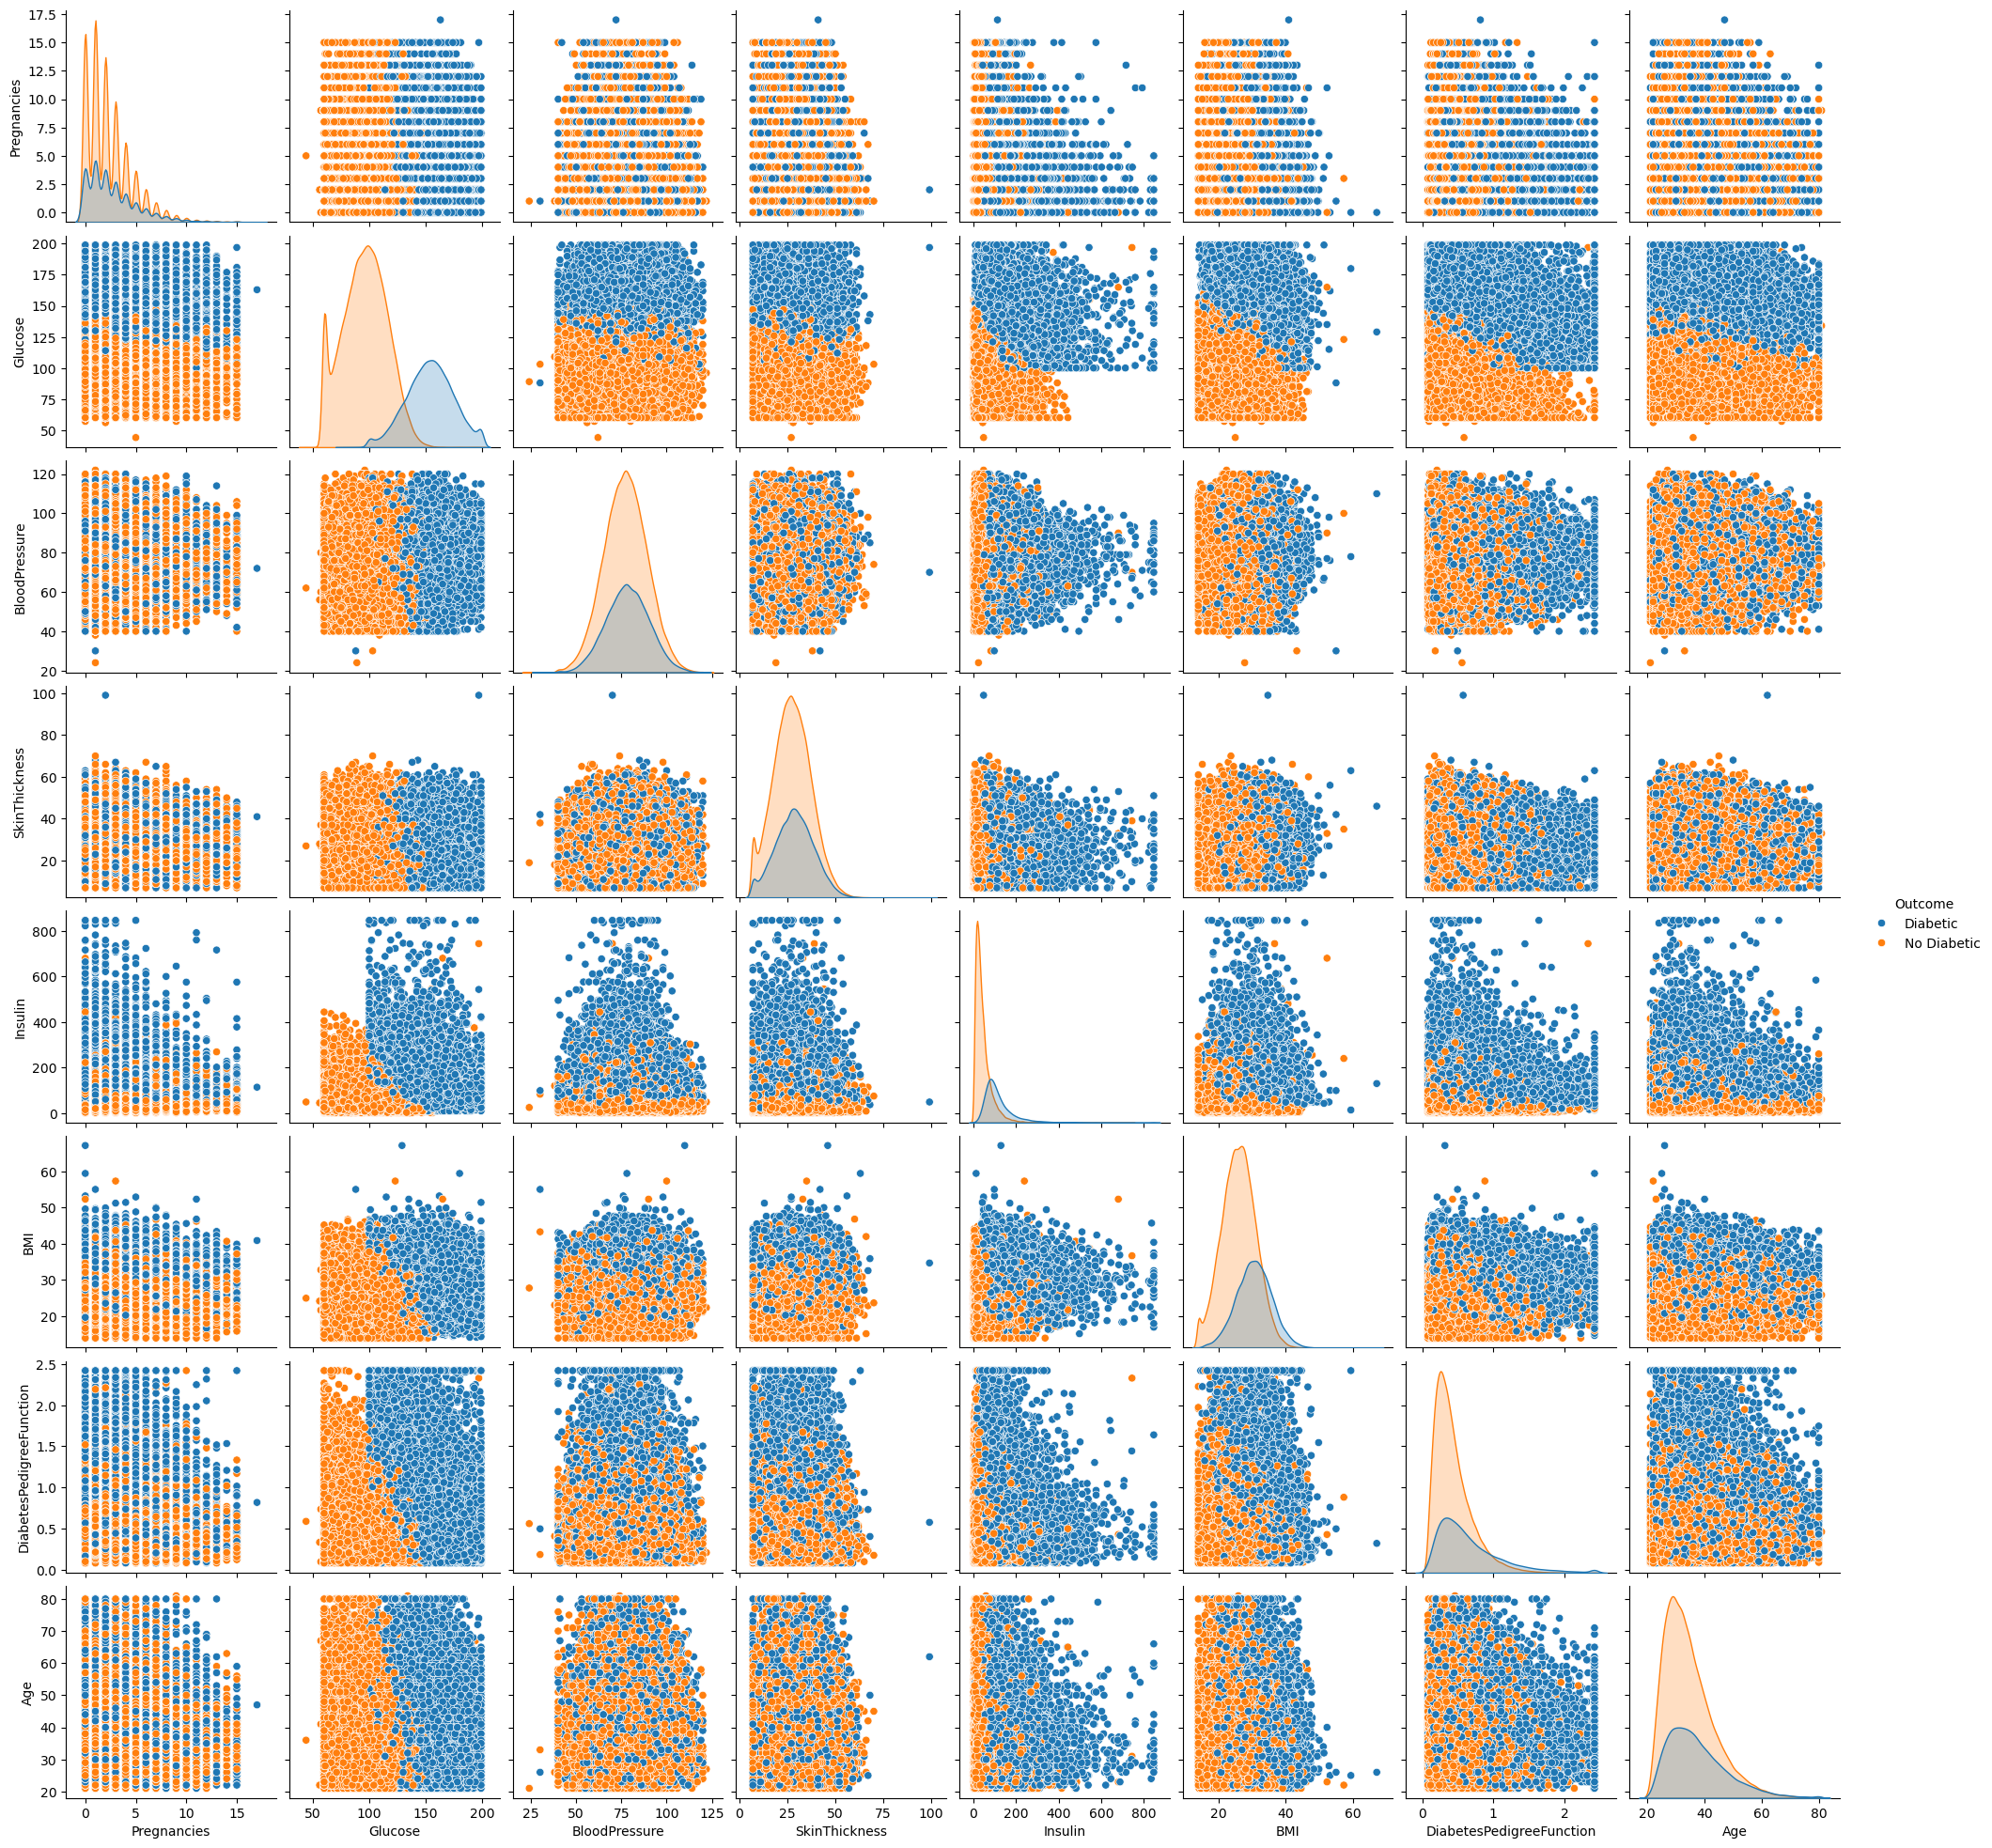

In [7]:
sns.pairplot(df,hue="Outcome")
#### Ploting how all parameters correlate with each other using seaborn pairplot

In [8]:
df = pd.read_csv('diabetes.csv')
df.head()
#### Visualizing the format in which the data is present.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [9]:
#### Defining the dependent and independent features
X = df.drop('Outcome',axis=1).values ### independent features
y = df['Outcome'].values #### dependent features

In [10]:
# ==========================================
# Define Features and Target
# ==========================================

X = df.drop('Outcome', axis=1).values

y = df['Outcome'].values

# ==========================================
# Train on Synthetic Data
# Test on Real PIMA Data
# ==========================================

X_train = d2.drop('Outcome', axis=1).values

y_train = d2['Outcome'].values

X_test = d1.drop('Outcome', axis=1).values

y_test = d1['Outcome'].values

In [12]:
#### Import the necessary libraries from Pytorch for model training
!pip install torch torchvision torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 4.0 MB/s  0:00:20m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 4.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.9/679.9 kB 7.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision] [torchvision]


In [13]:
##### Creating tensors for model training
X_train = torch.FloatTensor(X_train) ### independent feature should always be a float tensor
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [14]:
df.shape

(768, 9)

In [15]:
##### Creation of Model (ANN) using Pytorch

class ANN_Model(nn.Module):  #### Defining the hidden and connected features for adjusting accuracy
    def __init__(self,input_features=8,hidden1=20,hidden2=20,out_features=2):
        super().__init__()
        self.f_connected1=nn.Linear(input_features,hidden1)
        self.f_connected2=nn.Linear(hidden1,hidden2)
        self.out=nn.Linear(hidden2,out_features)
    def forward(self,x):    ### Forward Propogation
        x=F.relu(self.f_connected1(x))
        x=F.relu(self.f_connected2(x))
        x=self.out(x)
        return x  
    

In [16]:
#### instantiating the ANN Model
torch.manual_seed(20)
model=ANN_Model()

In [17]:
model.parameters

<bound method Module.parameters of ANN_Model(
  (f_connected1): Linear(in_features=8, out_features=20, bias=True)
  (f_connected2): Linear(in_features=20, out_features=20, bias=True)
  (out): Linear(in_features=20, out_features=2, bias=True)
)>

In [18]:
### Backward Propagation - Defining the loss function and Defining the Optimizer.
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

In [19]:
#### Running the loss function in for loop to optimize the model and increase the accuracy of prediction
epochs=500
final_losses=[]
for i in range(epochs):
    i=i+1
    y_pred=model.forward(X_train)
    loss=loss_function(y_pred,y_train)
    final_losses.append(loss)
    if i%10==1:
        print("Epoch number : {} and the Loss : {}".format(i,loss.item()))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch number : 1 and the Loss : 4.0080742835998535
Epoch number : 11 and the Loss : 0.34141573309898376
Epoch number : 21 and the Loss : 0.24721993505954742
Epoch number : 31 and the Loss : 0.22946761548519135
Epoch number : 41 and the Loss : 0.21917814016342163
Epoch number : 51 and the Loss : 0.21539811789989471
Epoch number : 61 and the Loss : 0.21122653782367706
Epoch number : 71 and the Loss : 0.20873981714248657
Epoch number : 81 and the Loss : 0.20655661821365356
Epoch number : 91 and the Loss : 0.20446531474590302
Epoch number : 101 and the Loss : 0.20243267714977264
Epoch number : 111 and the Loss : 0.20039668679237366
Epoch number : 121 and the Loss : 0.19833603501319885
Epoch number : 131 and the Loss : 0.19623737037181854
Epoch number : 141 and the Loss : 0.1941189467906952
Epoch number : 151 and the Loss : 0.19195382297039032
Epoch number : 161 and the Loss : 0.18970970809459686
Epoch number : 171 and the Loss : 0.1873898059129715
Epoch number : 181 and the Loss : 0.184928

In [20]:
#### Plotting and Visualizing the loss function
import matplotlib.pyplot as plt
%matplotlib inline

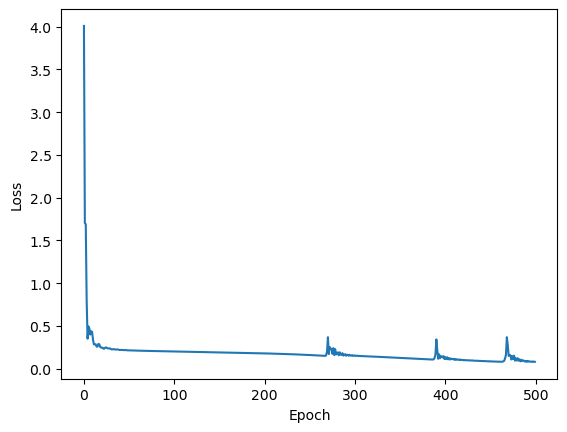

In [21]:
plt.plot(range(epochs),[loss.detach().numpy() for loss in final_losses])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [ ]:
### Prediction in X_test data
predictions=[]
with torch.no_grad():
    for i,data in enumerate(X_test):
        y_pred=model(data)
        predictions.append(y_pred.argmax().item())
        print(y_pred.argmax().item())

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,predictions)
cm

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True)
plt.xlabel('Actual Value')
plt.ylabel('Predicted Values')

In [ ]:
plt.show() #### Showing the heatmap of the confusion matrix

In [ ]:
###showing the accuracy score
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,predictions)
score

In [ ]:
### Saving the model
torch.save(model,'diabetes.pt')

In [ ]:
### Save and load the model
model = torch.load('diabetes.pt', weights_only=False)

In [ ]:
model.eval()

In [ ]:
### Prediction of new data point
list(df.iloc[0,:-1])

In [ ]:
### New Data
lst1 = [4.0, 80.0, 120.0, 30.0, 10.0, 25.0, 0.110, 45.0]

In [ ]:
df.head()

In [ ]:
new_data=torch.tensor(lst1)

In [ ]:
#### Prediction of new data using Pytorch
with torch.no_grad():
    print(model(new_data))
    print(model(new_data).argmax().item())